In [41]:
import os

import pandas as pd

genes_file = os.path.join("..", "..", "..", "Downloads", "five_utr_mutations.xlsx")
genes_df = pd.read_excel(genes_file, header=0)

genes_list = []
for gene in genes_df["Gene"]:
    if gene not in genes_list:
        genes_list.append(gene)

print(len(genes_list))



72


In [ ]:
from utrfx.model import TxperGene

json_path = os.path.join("tests", "data", "Ensembl_transcript_per_gene_dictionary.json")

tx_per_gene_class  = TxperGene(json_path)

canonical_tx_per_gene_dict = {}
for gene in genes_list:
    canonical_tx_per_gene_dict[gene] = tx_per_gene_class.ensembl_transcript(gene)

print(canonical_tx_per_gene_dict)
print(len(canonical_tx_per_gene_dict))



{'NMNAT1': 'ENST00000377205.6', 'ALPL': 'ENST00000374840.8', 'PCSK9': 'ENST00000302118.5', 'ZNF644': 'ENST00000337393.10', 'SLC16A1': 'ENST00000369626.8', 'MYOC': 'ENST00000037502.11', 'IRF6': 'ENST00000367021.8', 'POMC': 'ENST00000395826.7', 'MSH2': 'ENST00000233146.7', 'SPR': 'ENST00000234454.6', 'REEP1': 'ENST00000538924.7', 'PROC': 'ENST00000234071.8', 'BMPR2': 'ENST00000374580.10', 'MLH1': 'ENST00000231790.8', 'KLHDC8B': 'ENST00000332780.4', 'ACAD9': 'ENST00000308982.12', 'THPO': 'ENST00000647395.1', 'TERT': 'ENST00000310581.10', 'ANKH': 'ENST00000284268.8', 'NIPBL': 'ENST00000282516.13', 'HTR1A': 'ENST00000323865.5', 'SLC26A2': 'ENST00000286298.5', 'RARS2': 'ENST00000369536.10', 'PEX7': 'ENST00000318471.5', 'SLC26A4': 'ENST00000644269.2', 'CFTR': 'ENST00000003084.11', 'LPL': 'ENST00000650287.1', 'HR': 'ENST00000381418.9', 'ANK1': 'ENST00000289734.13', 'CDKN2A': 'ENST00000304494.10', 'GRHPR': 'ENST00000318158.11', 'PRPF4': 'ENST00000374198.5', 'ENG': 'ENST00000373203.9', 'ANKRD26'

In [ ]:
from utrfx.gtf_io import GTFio
from utrfx.genome import GRCh38

fpath_gtf = os.path.join("..", "..", "..", "Downloads", "Homo_sapiens.GRCh38.113.chr.gtf")

gtf_file = GTFio(fpath=fpath_gtf)
transcripts = gtf_file.extract_five_utrs_if_explicit(genome_build=GRCh38)


/Users/alejandropintoalba/Documents/project_utr/utrfx/src/utrfx/gtf_io.py:26: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gtf_df = pd.read_csv(self._fpath, sep = "\t", header = None, comment = "#")


In [5]:
from utrfx.util import fetch_cdna_from_ensembl, get_five_prime_sequence, uorf_extractor

tx_and_uofs_per_gene = {}
for gene, tx in canonical_tx_per_gene_dict.items():
    bare_tx = tx.split(".")[0]
    tx_cdna = fetch_cdna_from_ensembl(bare_tx)

    for tx in transcripts:
        if tx.tx_id == bare_tx:
            tx_found = tx
            break

    tx_five_utr_cdna = get_five_prime_sequence(tx_cdna, tx_found.five_utr)
    uorfs = uorf_extractor(tx_found.five_utr, tx_five_utr_cdna)

    tx_and_uofs_per_gene[gene] = [bare_tx, len(uorfs)]

In [6]:
print(tx_and_uofs_per_gene)

{'NMNAT1': ['ENST00000377205', 0], 'ALPL': ['ENST00000374840', 0], 'PCSK9': ['ENST00000302118', 1], 'ZNF644': ['ENST00000337393', 0], 'SLC16A1': ['ENST00000369626', 0], 'MYOC': ['ENST00000037502', 0], 'IRF6': ['ENST00000367021', 0], 'POMC': ['ENST00000395826', 0], 'MSH2': ['ENST00000233146', 0], 'SPR': ['ENST00000234454', 0], 'REEP1': ['ENST00000538924', 0], 'PROC': ['ENST00000234071', 1], 'BMPR2': ['ENST00000374580', 5], 'MLH1': ['ENST00000231790', 0], 'KLHDC8B': ['ENST00000332780', 2], 'ACAD9': ['ENST00000308982', 0], 'THPO': ['ENST00000647395', 2], 'TERT': ['ENST00000310581', 0], 'ANKH': ['ENST00000284268', 2], 'NIPBL': ['ENST00000282516', 3], 'HTR1A': ['ENST00000323865', 3], 'SLC26A2': ['ENST00000286298', 1], 'RARS2': ['ENST00000369536', 0], 'PEX7': ['ENST00000318471', 0], 'SLC26A4': ['ENST00000644269', 0], 'CFTR': ['ENST00000003084', 0], 'LPL': ['ENST00000650287', 0], 'HR': ['ENST00000381418', 4], 'ANK1': ['ENST00000289734', 0], 'CDKN2A': ['ENST00000304494', 0], 'GRHPR': ['ENST000

In [7]:
genes_with_uorfs = {}
genes_without_uorfs = {}

for gene, tx_uorfs in tx_and_uofs_per_gene.items():
    if tx_uorfs[1] >= 1:
        genes_with_uorfs[gene] = tx_uorfs
    else:
        genes_without_uorfs[gene] = tx_uorfs

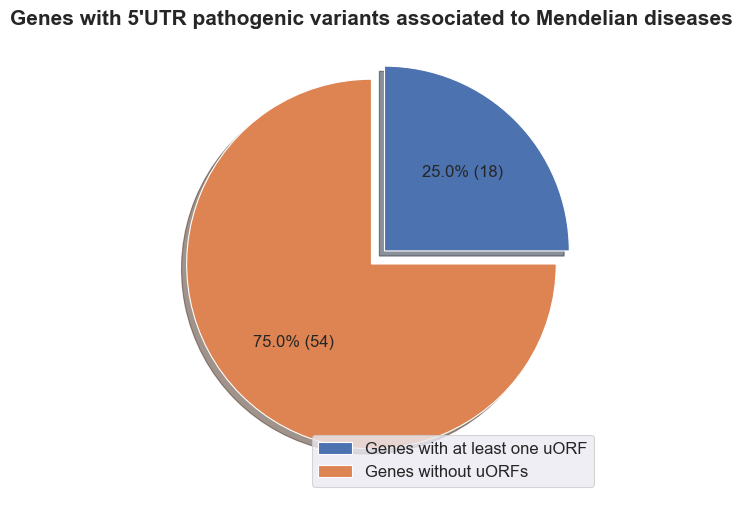

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

data = [len(genes_with_uorfs), len(genes_without_uorfs)]
labels = ["Genes with at least one uORF", "Genes without uORFs"]
explode = (0.1, 0)

def autopct_with_value(pct, allvals):
    absolute = round(pct / 100.*sum(allvals)) 
    return f'{pct}% ({absolute})'

sns.set("paper")
plt.figure(figsize=(6,6))
plt.pie(data, 
        labels=labels, 
        labeldistance=None, 
        explode=explode, 
        shadow=True, 
        autopct=lambda pct: autopct_with_value(pct, data),
        textprops={"fontsize": 12},
        radius=1,
    )
plt.legend(loc= "lower right",
           fontsize=12)
plt.title("Genes with 5'UTR pathogenic variants associated to Mendelian diseases",
          fontsize= 15,
          fontweight= "bold",)
plt.show()

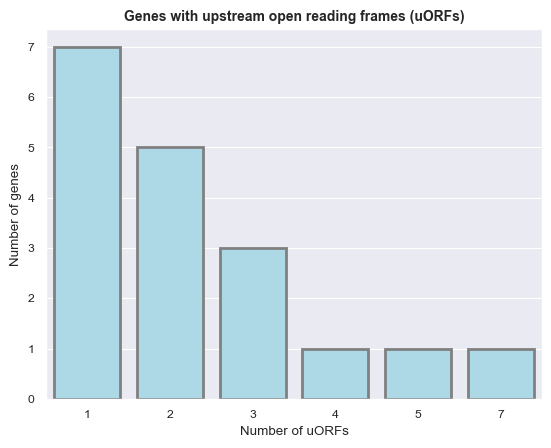

In [ ]:
data = {}

for tx, uorf in genes_with_uorfs.values():
    if uorf not in data:
        data[uorf] = 1
    else:
        data[uorf] += 1

df = pd.DataFrame(list(data.items()), columns=["Number of uORFs", "Number of genes"])

sns.barplot(data=df, 
            x="Number of uORFs", 
            y="Number of genes",
            linewidth=2, edgecolor=".5", facecolor="lightblue",            
        )
plt.title("Genes with upstream open reading frames (uORFs)",
          fontsize=10,
          fontweight="bold",
        )
plt.show()

In [ ]:
genes_with_uorfs_df = genes_df[genes_df["Gene"].isin(genes_with_uorfs.keys())]

print(genes_with_uorfs_df.head())

     Chr   Position  Ref  Alt     Gene
3   chr1   55039507    C    A    PCSK9
12  chr2  127418425    T    C     PROC
13  chr2  202376527  GGC  GAT    BMPR2
14  chr2  202376806    G    A    BMPR2
18  chr3   49171662    C    T  KLHDC8B


In [47]:
chr_of_genes_with_uorfs = []
for chr in genes_with_uorfs_df["Chr"]:
    if chr not in chr_of_genes_with_uorfs:
        chr_of_genes_with_uorfs.append(chr)

print(chr_of_genes_with_uorfs)


['chr1', 'chr2', 'chr3', 'chr5', 'chr8', 'chr10', 'chr11', 'chr14', 'chrX']
